In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import random
import numpy as np
import os
import pandas as pd
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from torch.cuda.amp import GradScaler, autocast  # Para Mixed Precision Training
from tqdm.notebook import tqdm # Import tqdm for progress bar

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
def set_seed(seed):
    """
    Sets random seeds for reproducibility across different libraries and environments.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # Ensures consistent hash-based operations (e.g., dictionary order)

    torch.manual_seed(seed) # Set CPU seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)       # Set current GPU seed
        torch.cuda.manual_seed_all(seed)   # Set all GPUs seed if multiple are used

        # Ensure deterministic behavior for cuDNN backend (for convolutional operations)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False # Disable cuDNN autotuner to ensure determinism

        # For full PyTorch 1.8+ determinism (may impact performance and cause errors for some ops)
        # The CUBLAS_WORKSPACE_CONFIG variable is needed for certain CUDA ops to be deterministic.
        # It must be set *before* any CUDA context is created (usually done by the time this function runs).
        try:
            os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:2" # For specific CUDA ops, e.g., certain reductions
            torch.use_deterministic_algorithms(True)
        except RuntimeError as e:
            # This can happen on older PyTorch versions or if deterministic algorithms cannot be used
            # for a specific operation.
            print(f"Warning: Could not set deterministic algorithms. Error: {e}")
            print("Some PyTorch operations might still be non-deterministic. Consider reviewing PyTorch version and operation types.")
            # If determinism is critical, you might want to stop execution or investigate further.

set_seed(42)

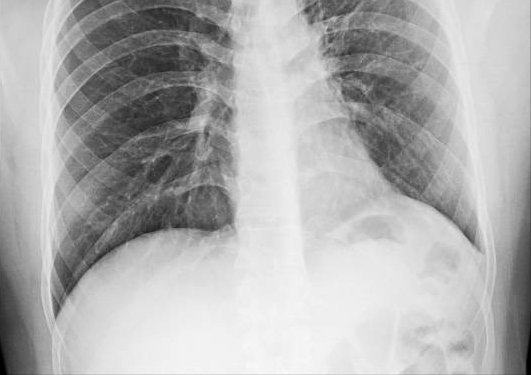

In [6]:
caminho_imagem = "D:/iniciacao_cientifica/untreated_images/images/Entry_ROI/img525.png"
imagem = Image.open(caminho_imagem)
display(imagem)

In [7]:
# Define the specific directory where all the relevant images are located
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\untreated_images\data\Data_Entry_Undergrad_PNG.csv"

# Reading the CSV file
all_xray_df = pd.read_csv(csv_path)

# Create a dictionary to map image filenames (from CSV) to their full file paths.
# We assume the 'Image Label' column in the CSV contains just the filename (e.g., 'img525.png').
all_image_paths_map = {}
# Use glob to find all PNGs *directly within* the specified Entry_ROI directory
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # The key for the dictionary should be just the filename, to match the 'Image Label' column
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

# Printing the number of actual image files found and total rows in the DataFrame
print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV:', all_xray_df.shape[0])

# Mapping the full image paths to the 'Image Label' column in the DataFrame.
# We are using .get() to safely handle cases where an image label from the CSV might not be found.
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# --- Crucial check for unmapped paths ---
# It's important to verify if all entries in your CSV found a corresponding image file.
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"Warning: {unmapped_images_count} images in the CSV could not be mapped to a file path "
          f"from '{image_entry_roi_dir}'. These rows will have 'path' as NaN.")
    # Option: Display a few unmapped entries to debug
    # print("\nSample unmapped CSV entries:")
    # display(all_xray_df[all_xray_df['path'].isnull()].head())
    
    # Option: Remove unmapped rows if they are not needed for further analysis
    # all_xray_df.dropna(subset=['path'], inplace=True)
    # print(f"Removed {unmapped_images_count} unmapped entries. Remaining rows: {len(all_xray_df)}")
else:
    print("All CSV entries successfully mapped to image file paths.")

# Displaying a sample of 3 rows from the DataFrame, now including the new 'path' column
display(all_xray_df.sample(3))

Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV: 1072


,Image Label,Finding Labels,Other,path
992,img993.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...
746,img747.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...
1066,img1067.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...


Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV: 1072
Removed 2 unmapped entries. Remaining rows: 1070

Sample of DataFrame with 'path' and 'is_tb' columns:


,Image Label,Finding Labels,path,is_tb
330,img331.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
233,img234.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
478,img479.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
519,img520.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
846,img849.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_10300\226715237.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values[:len(tb_categories)], ax=ax1, palette="viridis") # Slicing for safety


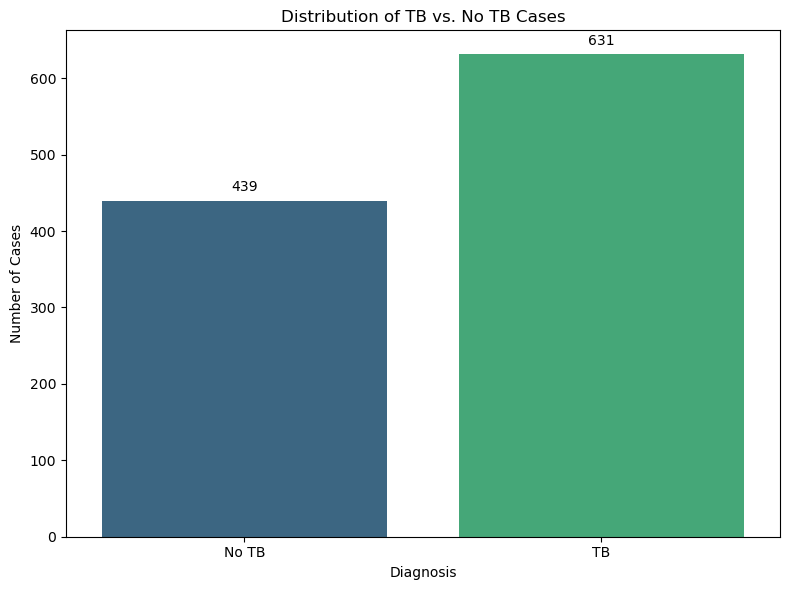

In [8]:
# Assuming previous imports are still active:
# import os, pandas as pd, glob, matplotlib.pyplot as plt, seaborn as sns, IPython.display as display

# Define the specific directory where all the relevant images are located
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\untreated_images\data\Data_Entry_Undergrad_PNG.csv"

# Reading the CSV file
all_xray_df = pd.read_csv(csv_path)

# --- CORRECTED IMAGE PATH MAPPING (Re-applied from previous turn) ---
# Create a dictionary to map image filenames (from CSV) to their full file paths.
# We assume the 'Image Label' column in the CSV contains just the filename (e.g., 'img525.png').
all_image_paths_map = {}
# Use glob to find all PNGs *directly within* the specified Entry_ROI directory
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # The key for the dictionary should be just the filename, to match the 'Image Label' column
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

# Display number of image files found and CSV entries for verification
print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV:', all_xray_df.shape[0])

# Mapping the full image paths to the 'Image Label' column in the DataFrame.
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Crucial check: Drop rows where no image path could be found, as these are unusable.
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"Warning: {unmapped_images_count} images in the CSV could not be mapped to a file path "
          f"from '{image_entry_roi_dir}'. These rows will be dropped.")
    all_xray_df.dropna(subset=['path'], inplace=True)
    print(f"Removed {unmapped_images_count} unmapped entries. Remaining rows: {len(all_xray_df)}")
else:
    print("All CSV entries successfully mapped to image file paths.")

all_xray_df.reset_index(drop=True, inplace=True)
# --- END CORRECTED IMAGE PATH MAPPING ---


# --- SIMPLIFIED 'is_tb' LABEL CREATION ---
# Given the clarification: The only finding labels are "No Findings" and "TB".
# Therefore, we can directly map 'TB' to 1 and 'No Findings' to 0.
# This makes the conversion explicit and robust for these two exact strings.

mapping_dict = {'TB': 1, 'No Findings': 0}
all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)

# It's good practice to ensure no NaNs in 'is_tb' if these are the *only* values
if all_xray_df['is_tb'].isnull().any():
    print(f"Critical Warning: Unexpected 'Finding Labels' found that are neither 'TB' nor 'No Findings'.")
    print("Unique unexpected labels:", all_xray_df[all_xray_df['is_tb'].isnull()]['Finding Labels'].unique())
    # Depending on the severity, you might want to stop execution or drop these rows.
    # For now, we'll continue but be aware.


# Display a sample of the DataFrame to show the new 'path' and 'is_tb' columns
print("\nSample of DataFrame with 'path' and 'is_tb' columns:")
display(all_xray_df[['Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

# --- PLOTTING THE DISTRIBUTION OF THE NEW 'is_tb' LABEL (unchanged, still plots the target) ---
# This plot directly shows the primary classification target (TB vs. No TB),
# which is what your model will learn to predict.
tb_label_counts = all_xray_df['is_tb'].value_counts().sort_index()

# Prepare data for plotting, ensuring both 0 and 1 are accounted for
tb_categories = ['No TB', 'TB']
# Use .get(key, default_value) to safely retrieve counts, in case one category has zero entries.
tb_values = [tb_label_counts.get(0, 0), tb_label_counts.get(1, 0)]

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
sns.barplot(x=tb_categories, y=tb_values[:len(tb_categories)], ax=ax1, palette="viridis") # Slicing for safety

ax1.set_title('Distribution of TB vs. No TB Cases')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')

# Add exact counts on top of bars for clarity
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV (before path mapping and cleaning): 1072
Removed 2 unmapped entries. Remaining rows: 1070

Original class counts (0: No TB, 1: TB):
is_tb
1    631
0    439
Name: count, dtype: int64

Minority class 'No TB (0)' count: 439
Undersampling majority class 'TB (1)' to match minority count.

Balanced class counts (0: No TB, 1: TB):
is_tb
1    439
0    439
Name: count, dtype: int64


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_10300\2796185981.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")


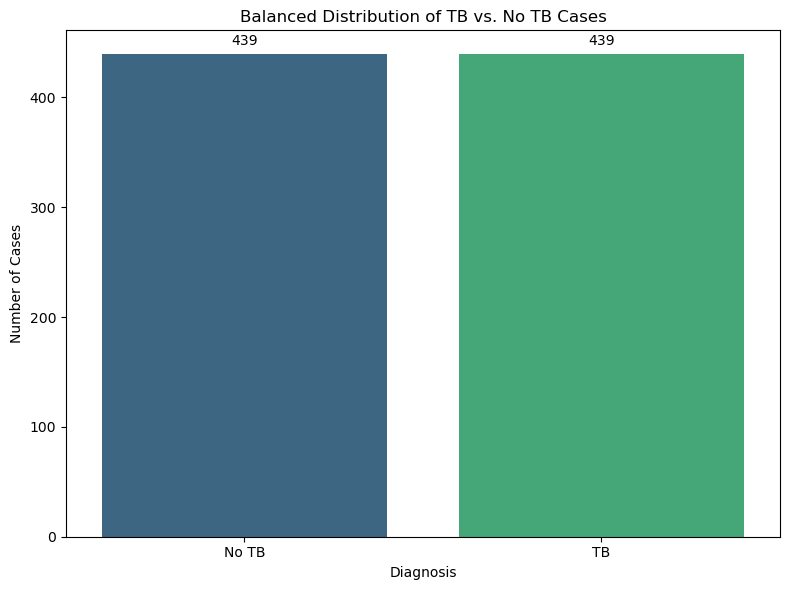


Sample of Balanced DataFrame:


,Image Label,Finding Labels,path,is_tb
528,img90.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
457,img19.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
33,img1005.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
339,img608.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
300,img809.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1


In [9]:
# --- Correct Image Path Mapping (Applied from our previous discussion) ---
# Define the specific directory where all the relevant images are located
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\untreated_images\data\Data_Entry_Undergrad_PNG.csv"

# Reading the CSV file
all_xray_df = pd.read_csv(csv_path)

# Create a dictionary to map image filenames (from CSV) to their full file paths.
# We assume the 'Image Label' column in the CSV contains just the filename (e.g., 'img525.png').
all_image_paths_map = {}
# Use glob to find all PNGs *directly within* the specified Entry_ROI directory
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # The key for the dictionary should be just the filename, to match the 'Image Label' column
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

# Display number of image files found and CSV entries for verification
print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV (before path mapping and cleaning):', all_xray_df.shape[0])

# Mapping the full image paths to the 'Image Label' column in the DataFrame.
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Crucial check: Drop rows where no image path could be found, as these are unusable.
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"Warning: {unmapped_images_count} images in the CSV could not be mapped to a file path "
          f"from '{image_entry_roi_dir}'. These rows will be dropped.")
    all_xray_df.dropna(subset=['path'], inplace=True)
    print(f"Removed {unmapped_images_count} unmapped entries. Remaining rows: {len(all_xray_df)}")
else:
    print("All CSV entries successfully mapped to image file paths.")

all_xray_df.reset_index(drop=True, inplace=True)
# --- End of Corrected Image Path Mapping ---


# --- Create the 'is_tb' label explicitly (Simplified based on your rule) ---
# The only finding labels are "No Findings" and "TB".
mapping_dict = {'TB': 1, 'No Findings': 0}
all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)

# Verify no unexpected labels appeared
if all_xray_df['is_tb'].isnull().any():
    print(f"Critical Warning: Unexpected 'Finding Labels' found that are neither 'TB' nor 'No Findings'.")
    print("Unique unexpected labels:", all_xray_df[all_xray_df['is_tb'].isnull()]['Finding Labels'].unique())
    # Depending on the issue, you might need to handle these rows (e.g., re-assign, drop).

# Display original class counts based on the 'is_tb' column
original_counts = all_xray_df['is_tb'].value_counts()
print("\nOriginal class counts (0: No TB, 1: TB):")
print(original_counts)


# --- Class Balancing: Undersampling the Majority Class ---
# Separate the two classes based on the 'is_tb' column
no_tb_df = all_xray_df[all_xray_df['is_tb'] == 0]
tb_df = all_xray_df[all_xray_df['is_tb'] == 1]

# Determine which class is majority and minority
if len(no_tb_df) > len(tb_df):
    majority_df = no_tb_df
    minority_df = tb_df
    majority_label = 'No TB (0)'
    minority_label = 'TB (1)'
else: # If TB is majority or counts are equal
    majority_df = tb_df
    minority_df = no_tb_df
    majority_label = 'TB (1)'
    minority_label = 'No TB (0)'

# Count of the minority class (this is the target count for both classes after balancing)
minority_count = len(minority_df)
print(f"\nMinority class '{minority_label}' count: {minority_count}")
print(f"Undersampling majority class '{majority_label}' to match minority count.")

# Resample the majority class to match the minority count (undersampling)
majority_resampled_df = majority_df.sample(n=minority_count, random_state=42)

# Combine the resampled majority rows with the minority rows (which are kept entirely)
balanced_df = pd.concat([majority_resampled_df, minority_df]).reset_index(drop=True)

# Verify the new class counts
balanced_counts = balanced_df['is_tb'].value_counts()
print("\nBalanced class counts (0: No TB, 1: TB):")
print(balanced_counts)


# --- Plotting the Balanced Dataset (displayed in notebook) ---
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# Prepare data for plotting, ensuring both 0 and 1 are accounted for
tb_categories = ['No TB', 'TB']
# Use .get(key, default_value) to safely retrieve counts, in case a category has zero entries.
tb_values = [balanced_counts.get(0, 0), balanced_counts.get(1, 0)]

sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")

ax1.set_title('Balanced Distribution of TB vs. No TB Cases')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')

# Add exact counts on top of bars for clarity
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show() # Display the plot in the Jupyter Notebook

# Display a sample of the balanced DataFrame
print("\nSample of Balanced DataFrame:")
display(balanced_df[['Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

In [10]:
# Assuming 'balanced_df' is already in memory from the previous successful step.

# Verify the initial balance (re-print for clarity, though it was printed before)
print("Initial class distribution in balanced_df:")
print(balanced_df['is_tb'].value_counts()) # Using .value_counts() directly

# Split the data into train (80%) and temp (20%) sets
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,  # 20% for temp (validation + test)
    stratify=balanced_df['is_tb'],  # Stratify based on 'is_tb' to maintain class balance
    random_state=42 # Ensure reproducibility of the split
)

# Split the temp set into validation (10%) and test (10%) sets
# Since temp is 20% of the data, splitting it 50%/50% ensures 10% for validation and 10% for test.
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # 50% of temp for test (which is 10% of total)
    stratify=temp_df['is_tb'],  # Stratify again to maintain class balance
    random_state=42
)

# Verify the sizes and class distribution for each new set (essential for in-notebook verification)
print("\nTrain set size and class distribution:")
print(f"Size: {len(train_df)}")
print(train_df['is_tb'].value_counts())

print("\nValidation set size and class distribution:")
print(f"Size: {len(val_df)}")
print(val_df['is_tb'].value_counts())

print("\nTest set size and class distribution:")
print(f"Size: {len(test_df)}")
print(test_df['is_tb'].value_counts())

print("\nTrain, validation, and test sets have been successfully created and are in memory.")

# You can optionally display a sample of each DataFrame if you wish (e.g., display(train_df.head()))

Initial class distribution in balanced_df:
is_tb
1    439
0    439
Name: count, dtype: int64

Train set size and class distribution:
Size: 702
is_tb
1    351
0    351
Name: count, dtype: int64

Validation set size and class distribution:
Size: 88
is_tb
0    44
1    44
Name: count, dtype: int64

Test set size and class distribution:
Size: 88
is_tb
1    44
0    44
Name: count, dtype: int64

Train, validation, and test sets have been successfully created and are in memory.


Visualizing class distributions for train, validation, and test sets:


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_10300\4165760009.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_10300\4165760009.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_10300\4165760009.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)


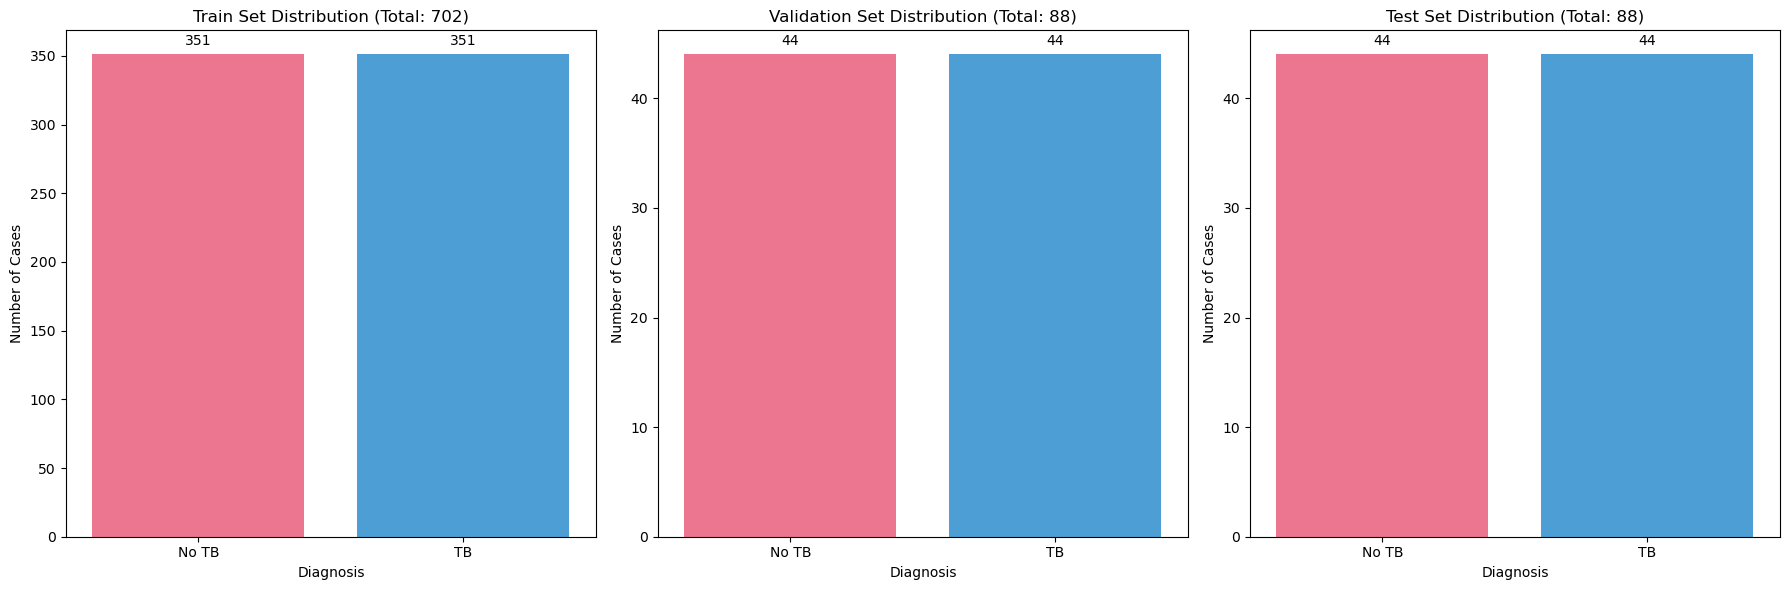

In [11]:
print("Visualizing class distributions for train, validation, and test sets:")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjust figsize as needed for better readability

# Define common properties for categories and colors (optional, but good for consistency)
tb_categories = ['No TB', 'TB']
colors = ['#FF6384', '#36A2EB'] # Or use a seaborn palette like "viridis" or "plasma"


# --- Plot for Train Set ---
train_counts = train_df['is_tb'].value_counts().sort_index()
# Use .get() to safely retrieve counts, in case one category has zero entries (unlikely for balanced sets)
train_values = [train_counts.get(0, 0), train_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)
axes[0].set_title(f'Train Set Distribution (Total: {len(train_df)})')
axes[0].set_ylabel('Number of Cases')
axes[0].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')


# --- Plot for Validation Set ---
val_counts = val_df['is_tb'].value_counts().sort_index()
val_values = [val_counts.get(0, 0), val_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
axes[1].set_title(f'Validation Set Distribution (Total: {len(val_df)})')
axes[1].set_ylabel('Number of Cases')
axes[1].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')


# --- Plot for Test Set ---
test_counts = test_df['is_tb'].value_counts().sort_index()
test_values = [test_counts.get(0, 0), test_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)
axes[2].set_title(f'Test Set Distribution (Total: {len(test_df)})')
axes[2].set_ylabel('Number of Cases')
axes[2].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show() # Display the plots directly in the Jupyter Notebook output

In [ ]:
# Define the custom dataset class (adapted for your DataFrame)
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): DataFrame with columns 'path' and 'is_tb'.
            transform (callable, optional): Transformations to be applied to the images.
        """
        self.dataframe = dataframe
        self.transform = transform
        # Verify the integrity of image paths right after initialization
        self.dataframe = self._validate_image_paths()

    def _validate_image_paths(self):
        """
        Removes entries with invalid image paths.
        Uses pandas.Series.apply for more efficient checking and boolean indexing for filtering.
        """
        initial_count = len(self.dataframe)
        
        # Create a boolean mask indicating which paths exist
        valid_paths_mask = self.dataframe['path'].apply(os.path.exists)
        
        # Log warnings for missing images
        invalid_paths_df = self.dataframe.loc[~valid_paths_mask]
        if not invalid_paths_df.empty:
            print(f"Warning: {len(invalid_paths_df)} images not found. Examples:")
            for img_path in invalid_paths_df['path'].head(5): # Print only first 5 warnings
                print(f"  - {img_path}")
            
        validated_dataframe = self.dataframe[valid_paths_mask].reset_index(drop=True)
        
        if len(validated_dataframe) == 0:
            raise ValueError("No valid images found in the DataFrame after path validation.")
        
        if len(validated_dataframe) < initial_count:
            print(f"Dataset reduced from {initial_count} to {len(validated_dataframe)} valid images.")
            
        return validated_dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # We assume _validate_image_paths has already filtered out non-existent paths.
        # Any error here likely indicates a corrupted image file or a permission issue.
        img_path = self.dataframe.iloc[idx]['path']
        try:
            image = Image.open(img_path).convert('RGB')
            label = self.dataframe.iloc[idx]['is_tb']
            
            # Convert label directly to torch.Tensor with float32 dtype
            label = torch.tensor(label, dtype=torch.float32)
            
            if self.transform:
                image = self.transform(image)
                
            return image, label
        except Exception as e:
            # CRITICAL: Raise an exception instead of returning None.
            # Returning None will cause issues with DataLoader's collate_fn.
            raise RuntimeError(f"Error loading or processing image {img_path} at index {idx}: {e}") from e

# Function to compute dataset statistics (global mean and std)
def compute_dataset_stats(loader):
    """
    Computes the global pixel-wise mean and standard deviation for normalization
    across all images in the dataset, per channel.
    """
    total_pixels = torch.zeros(3)      # Accumulator for total pixels (H*W*N) per channel
    sum_pixel_values = torch.zeros(3)   # Accumulator for sum of pixel values per channel
    sum_squared_pixel_values = torch.zeros(3) # Accumulator for sum of squared pixel values per channel

    # Wrap the loader with tqdm for a progress bar
    print("Calculating dataset mean and std...")
    for i, (images, _) in enumerate(tqdm(loader, desc="Calculating Stats")):
        # Ensure batch is not empty and contains expected number of dimensions
        if images is None or images.numel() == 0 or images.dim() != 4: # batch, channels, H, W
            print(f"Skipping empty or invalid batch {i}.") # This print would break tqdm bar, so handle carefully
            continue
            
        # Reshape images to (batch_size, channels, H*W)
        images_flat = images.view(images.size(0), images.size(1), -1)

        # Accumulate sums
        sum_pixel_values += images_flat.sum(dim=[0, 2])
        sum_squared_pixel_values += (images_flat ** 2).sum(dim=[0, 2])
        
        # Accumulate total number of pixels added from this batch
        total_pixels += images_flat.size(0) * images_flat.size(2)

    if total_pixels.sum() == 0: # Check if any valid pixel data was processed
        raise ValueError("No valid image data processed to compute statistics.")

    # Calculate global mean: E[X] = sum(X) / N
    mean = sum_pixel_values / total_pixels

    # Calculate global standard deviation: std = sqrt(E[X^2] - (E[X])^2)
    variance = (sum_squared_pixel_values / total_pixels) - (mean ** 2)
    # Ensure variance is non-negative due to potential floating point inaccuracies
    std = torch.sqrt(torch.clamp(variance, min=0.0)) # Clamp to 0.0 to prevent sqrt(negative) issues
    
    return mean, std


# --- Main execution block ---

# train_df should already be in memory from the data splitting step in the notebook.
# If you run this block independently, ensure 'train_df' is defined.
if 'train_df' not in locals():
    print("Error: 'train_df' not found in memory. Please ensure previous data loading and splitting cells were run.")
    raise NameError("'train_df' not found. It should be in memory from previous steps.")

# Define minimal transforms (no normalization yet, as we are calculating it)
temp_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a consistent size
    transforms.ToTensor()          # Convert PIL Image to PyTorch Tensor, scales pixels to [0.0, 1.0]
])

# Create a temporary dataset and DataLoader using the in-memory train_df
try:
    print(f"\nAttempting to compute stats on {len(train_df)} images in train_df.")
    temp_dataset = ChestXRayDataset(dataframe=train_df, transform=temp_transforms)
    
    temp_loader = DataLoader(
        temp_dataset,
        batch_size=32, # Use a reasonable batch size for stats calculation
        shuffle=False, # No need to shuffle for stats calculation
        num_workers=0  # Set to 0 for Windows compatibility; for performance on non-Windows, set > 0
    )
    
    # Compute the mean and std
    computed_mean, computed_std = compute_dataset_stats(temp_loader)
    
    # Print with formatting for clarity
    print("\n--- Computed Dataset Statistics ---")
    print(f"Mean (RGB channel-wise):     {computed_mean.tolist()}")
    print(f"Standard Dev (RGB channel-wise): {computed_std.tolist()}")
    print("---------------------------------")
    
    # Store these values for later use in normalization transforms
    global_dataset_mean = computed_mean
    global_dataset_std = computed_std

except Exception as e:
    print(f"An error occurred during dataset stats computation: {e}")
    # Consider what action to take if stats computation fails (e.g., exit, use default values)


Attempting to compute stats on 702 images in train_df.
Calculating dataset mean and std...
An error occurred during dataset stats computation: name 'tqdm' is not defined
